# Assignment4 - Neural Networks

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


## Exercise 1 - Exploring and optimizing neural network hyperparameters

In [1]:
# Optional for clear plotting on Macs
# %config InlineBackend.figure_format='retina'

# Some of the network training leads to warnings. When we know and are OK with 
#  what's causing the warning and simply don't want to see it, we can use the 
#  following code. Run this block
#  to disable warnings
import sys
import os
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = 'ignore'

In [2]:
import numpy as np
from sklearn.model_selection import PredefinedSplit

#-----------------------------------------------------------------------------
# Create the data
#-----------------------------------------------------------------------------
# Data generation function to create a checkerboard-patterned dataset
def make_data_normal_checkerboard(n, noise=0):
    n_samples = int(n/4)
    shift = 0.5
    c1a = np.random.randn(n_samples,2)*noise + [-shift, shift]
    c1b = np.random.randn(n_samples,2)*noise + [shift, -shift]
    c0a = np.random.randn(n_samples,2)*noise + [shift, shift]
    c0b = np.random.randn(n_samples,2)*noise + [-shift, -shift]
    X = np.concatenate((c1a,c1b,c0a,c0b),axis=0)
    y = np.concatenate((np.ones(2*n_samples), np.zeros(2*n_samples)))
    
    # Set a cutoff to the data and fill in with random uniform data:
    cutoff = 1.25
    indices_to_replace = np.abs(X)>cutoff
    for index,value in enumerate(indices_to_replace.ravel()):
        if value:
            X.flat[index] = np.random.rand()*2.5-1.25
    return (X,y)

# Training datasets
np.random.seed(42)
noise = 0.45
X_train,y_train = make_data_normal_checkerboard(500, noise=noise)
    
# Validation and test data
X_val,y_val = make_data_normal_checkerboard(500, noise=noise)
X_test,y_test = make_data_normal_checkerboard(500, noise=noise)

# For RandomSeachCV, we will need to combine training and validation sets then
#  specify which portion is training and which is validation
# Also, for the final performance evaluation, train on all of the training AND 
#  validation data
X_train_plus_val = np.concatenate((X_train, X_val), axis=0)
y_train_plus_val = np.concatenate((y_train, y_val), axis=0)

# Create a predefined train/test split for RandomSearchCV (to be used later)
validation_fold = np.concatenate((-1*np.ones(len(y_train)), np.zeros(len(y_val))))
train_val_split = PredefinedSplit(validation_fold)

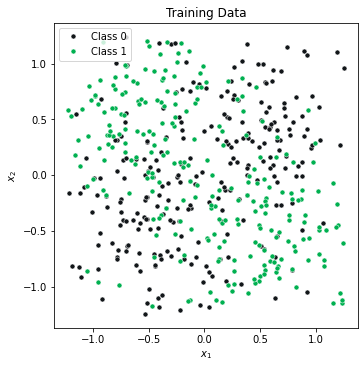

In [3]:
import matplotlib.pyplot as plt

# Code to plot the sample data
def plot_data(ax,X,y,title, limits):
    # Select the colors to use in the plots
    color0 = '#121619' # Dark grey
    color1 = '#00B050' # Green
    color_boundary='#858585'
    
    # Separate samples by class
    samples0 = X[y==0]
    samples1 = X[y==1]

    ax.plot(samples0[:,0],samples0[:,1],
        marker='o',
        markersize=5,
        linestyle="None",
        color=color0,
        markeredgecolor='w',
        markeredgewidth=0.5,
        label='Class 0')
    ax.plot(samples1[:,0],samples1[:,1],
        marker='o',
        markersize=5,
        linestyle="None",
        color=color1,
        markeredgecolor='w',
        markeredgewidth=0.5,
        label='Class 1')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(loc='upper left')
    ax.set_aspect('equal')

fig, ax = plt.subplots(constrained_layout=True, figsize=(5,5))
limits = [-1.25, 1.25, -1.25, 1.25]
plot_data(ax, X_train, y_train, 'Training Data', limits)

**1.1 Visualize teh impact of different hyperparameter choices**

In [4]:
from sklearn.neural_network import MLPClassifier

archs = [(2, 2), (5, 5), (30, 30)]
lrs = [0.0001, 0.01, 1]
regs = [0, 1, 10]
batches = [5, 50, 500]

def plot_decision_boundary(ax, clf, X, y, title):
    x_min, x_max = -1.25, 1.25
    y_min, y_max = -1.25, 1.25
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, colors=['#121619', '#00B050'])
    plot_data(ax, X, y, title, [x_min, x_max, y_min, y_max])

In [5]:
hyperparams = {
    'Architecture': ('hidden_layer_sizes', [(2, 2), (5, 5), (30, 30)]),
    'Learning Rate': ('learning_rate_init', [0.0001, 0.01, 1]),
    'Regularization': ('alpha', [0, 1, 10]),
    'Batch Size': ('batch_size', [5, 50, 500])
}

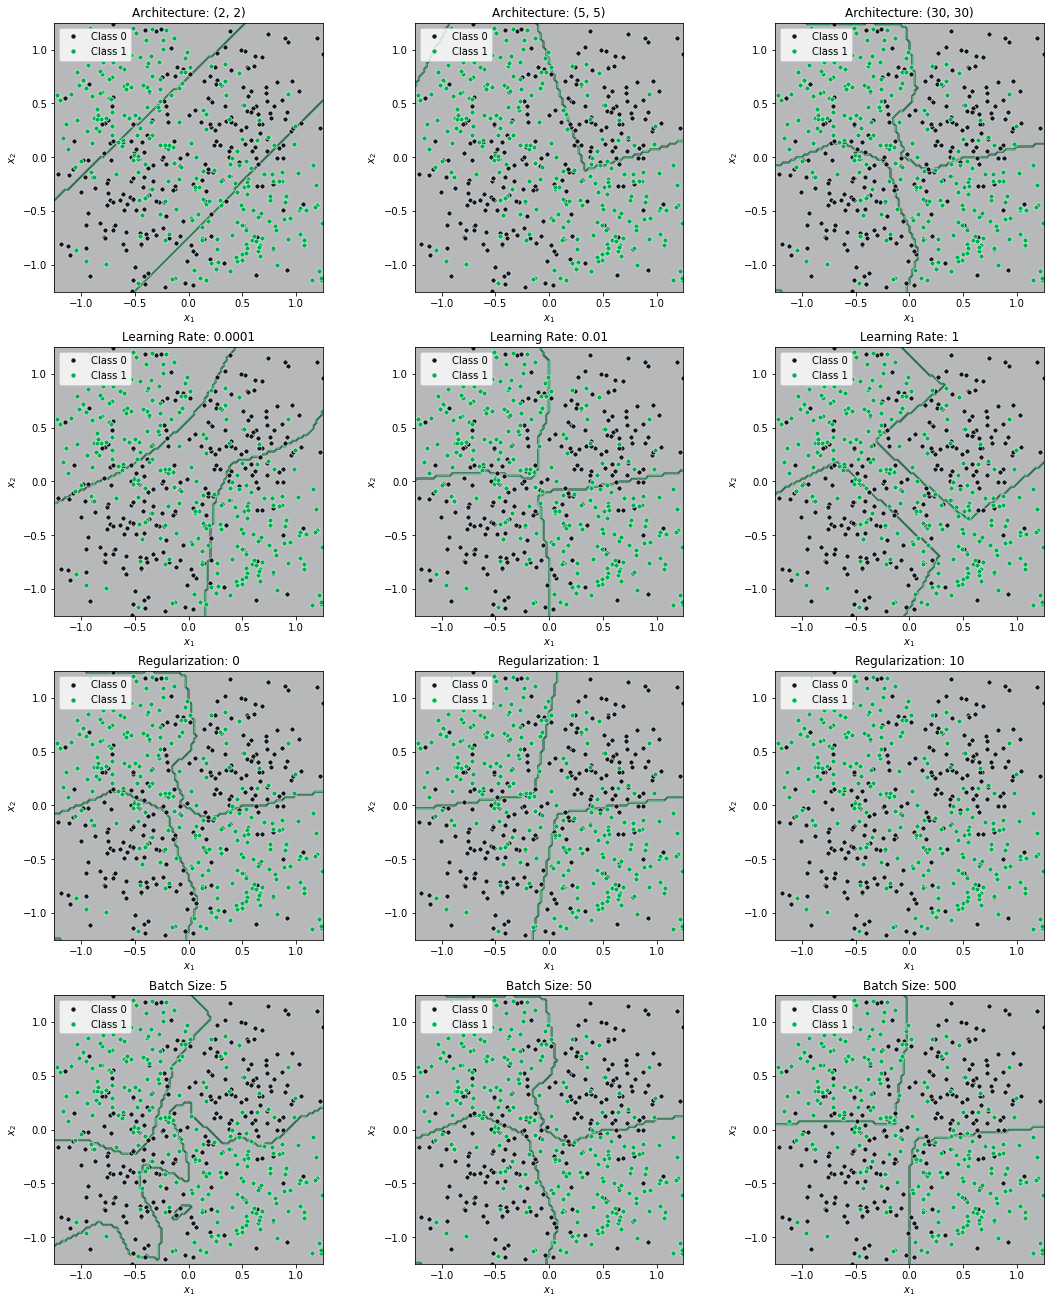

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 18), constrained_layout=True)

for row_idx, (label, (param_name, values)) in enumerate(hyperparams.items()):
    for col_idx, val in enumerate(values):
        ax = axes[row_idx, col_idx]
        
        mlp_params = {
            'hidden_layer_sizes': (30, 30),
            'learning_rate_init': 0.03,
            'alpha': 0,
            'batch_size': 50,
            'solver': 'sgd',
            'tol': 1e-5,
            'early_stopping': False,
            'activation': 'relu',
            'n_iter_no_change': 1000,
            'max_iter': 500,
            'random_state': 42 
        }
        mlp_params[param_name] = val
        
        mlp = MLPClassifier(**mlp_params)
        mlp.fit(X_train, y_train)
        
        title = f"{label}: {val}"
        plot_decision_boundary(ax, mlp, X_train, y_train, title)

plt.show()

**1.2 Manual hyperparameter tuning**

To address the neural network's sensitivity to initial weight values, I did not rely on a single training run. Instead, I implemented a robust evaluation process by using three distinct random seeds [1, 50, 500] to simulate different starting conditions for the network. And calculating the mean validation accuracy across these three runs for every hyperparameter value

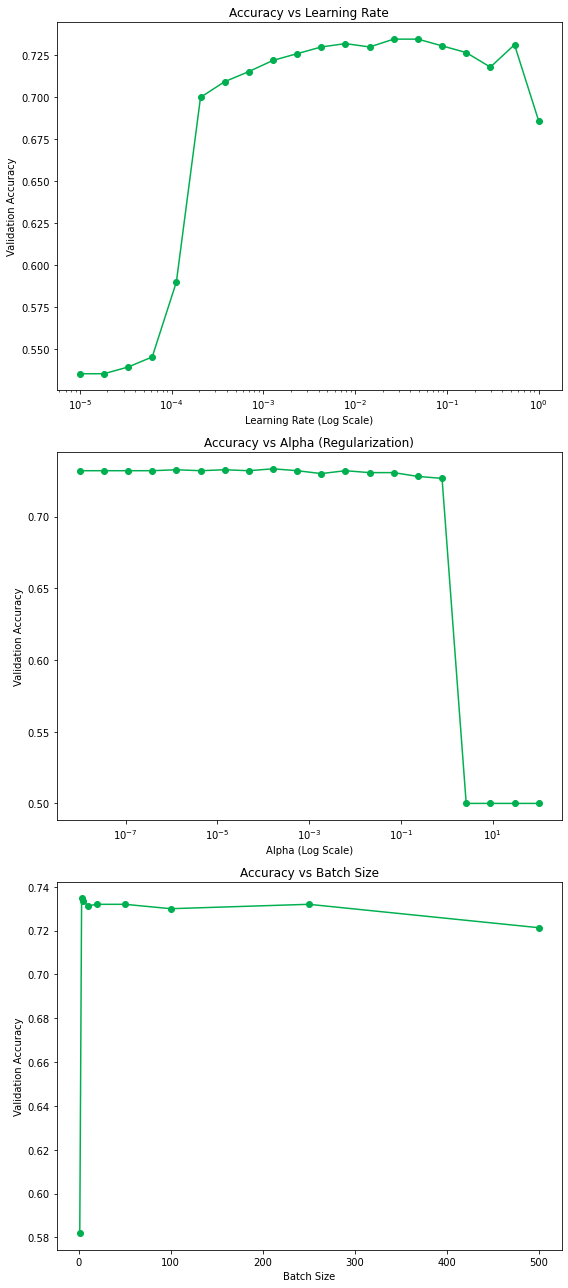

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

learning_rates = np.logspace(-5, 0, 20)  # 10^-5 to 10^0
alphas = np.logspace(-8, 2, 20)          # 10^-8 to 10^2
batch_sizes = [1, 3, 5, 10, 20, 50, 100, 250, 500]

base_params = {
    'hidden_layer_sizes': (30, 30),
    'learning_rate_init': 0.03,
    'alpha': 0,
    'batch_size': 50,
    'solver': 'sgd',
    'max_iter': 500,
    'random_state': None 
}

def get_scores(param_name, values):
    train_scores = []
    val_scores = []
    for val in values:
        params = base_params.copy()
        params[param_name] = val
        
        seeds = [1, 50, 500]
        tmp_val_acc = []
        for s in seeds:
            params['random_state'] = s
            mlp = MLPClassifier(**params).fit(X_train, y_train)
            tmp_val_acc.append(mlp.score(X_val, y_val))
            
        val_scores.append(np.mean(tmp_val_acc))
    return val_scores

fig, axes = plt.subplots(3, 1, figsize=(8, 18), constrained_layout=True)
# Plot 1: Learning Rate
val_lr = get_scores('learning_rate_init', learning_rates)
axes[0].semilogx(learning_rates, val_lr, 'o-', color='#00B050')
axes[0].set_title('Accuracy vs Learning Rate')
axes[0].set_xlabel('Learning Rate (Log Scale)')
axes[0].set_ylabel('Validation Accuracy')

# Plot 2: Regularization (Alpha)
val_alpha = get_scores('alpha', alphas)
axes[1].semilogx(alphas, val_alpha, 'o-', color='#00B050')
axes[1].set_title('Accuracy vs Alpha (Regularization)')
axes[1].set_xlabel('Alpha (Log Scale)')
axes[1].set_ylabel('Validation Accuracy')

# Plot 3: Batch Size
val_batch = get_scores('batch_size', batch_sizes)
axes[2].plot(batch_sizes, val_batch, 'o-', color='#00B050')
axes[2].set_title('Accuracy vs Batch Size')
axes[2].set_xlabel('Batch Size')
axes[2].set_ylabel('Validation Accuracy')

plt.tight_layout()
plt.show()

In [8]:
# 1. Finding the Best Learning Rate
best_lr_idx = np.argmax(val_lr) # Find index of highest accuracy
best_lr = learning_rates[best_lr_idx]
best_lr_score = val_lr[best_lr_idx]

# 2. Finding the Best Alpha
best_alpha_idx = np.argmax(val_alpha)
best_alpha = alphas[best_alpha_idx]
best_alpha_score = val_alpha[best_alpha_idx]

# 3. Finding the Best Batch Size
best_batch_idx = np.argmax(val_batch)
best_batch = batch_sizes[best_batch_idx]
best_batch_score = val_batch[best_batch_idx]

print("--- Optimal Hyperparameters Found ---")
print(f"Best Learning Rate: {best_lr:.6f} (Accuracy: {best_lr_score:.4f})")
print(f"Best Alpha:         {best_alpha:.6f} (Accuracy: {best_alpha_score:.4f})")
print(f"Best Batch Size:    {best_batch} (Accuracy: {best_batch_score:.4f})")

--- Optimal Hyperparameters Found ---
Best Learning Rate: 0.026367 (Accuracy: 0.7347)
Best Alpha:         0.000162 (Accuracy: 0.7333)
Best Batch Size:    3 (Accuracy: 0.7347)


**Optimal Hyperparameter Selection**        

Based on the validation performance plots and the exact data points extracted from the MLPClassifier.score method, I have selected the following optimal hyperparameters:
- Learning rate: The accuracy vs. learning rate plot shows a significant increase after $10^{-4}$ and reaches its peak at approximately 0.026367 .
- Alpha: I selected an alpha of $0.000162$ because it yielded the highest validation accuracy before the sharp performance drop-off observed when $alpha > 1$.
- Batch Size: Although the plot displays some noise due to initialization sensitivity, a batch size of $3$ achieved the highest overall accuracy ($0.7393$). I selected this because smaller batches introduce stochasticity that helps the model navigate the complex, non-linear boundaries of the checkerboard pattern more effectively than larger, more stable batches.        

Therefore, I choose learning rate(0.026367), alpha($0.000162$) and the batch size 3 to be my hyperparameter.

**1.3 Manual hyperparameter tuning II**

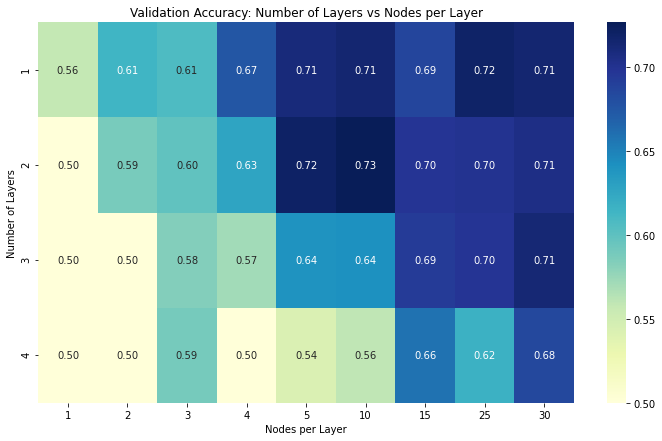

Highest Accuracy: 0.7267
Best Configuration: Layers=2, Nodes=10


In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

# Optimized parameters from 1.2
best_lr = 0.026367
best_alpha = 0.000162
best_batch = 3

nodes_per_layer = [1, 2, 3, 4, 5, 10, 15, 25, 30]
num_layers_list = [1, 2, 3, 4]
seeds = [1, 50, 500]

# Initialize results matrix
results_matrix = np.zeros((len(num_layers_list), len(nodes_per_layer)))

# Grid search for architecture
for i, layers in enumerate(num_layers_list):
    for j, nodes in enumerate(nodes_per_layer):
        # Create symmetric architecture (e.g., (15, 15) for 2 layers)
        current_arch = tuple([nodes] * layers)
        
        trial_scores = []
        for s in seeds:
            mlp = MLPClassifier(hidden_layer_sizes=current_arch, learning_rate_init=best_lr, alpha=best_alpha, batch_size=best_batch, solver='sgd', max_iter=500,
            random_state=s, early_stopping=False,n_iter_no_change=1000, tol=1e-5)
            mlp.fit(X_train, y_train)
            trial_scores.append(mlp.score(X_val, y_val))
        
        results_matrix[i, j] = np.mean(trial_scores)

# Heatmap Visualization
plt.figure(figsize=(12, 7))
ax = sns.heatmap(results_matrix, annot=True, fmt=".2f", xticklabels=nodes_per_layer, yticklabels=num_layers_list, cmap='YlGnBu')

plt.title('Validation Accuracy: Number of Layers vs Nodes per Layer')
plt.xlabel('Nodes per Layer')
plt.ylabel('Number of Layers')
plt.show()

# Find the absolute best for reference
max_idx = np.unravel_index(np.argmax(results_matrix, axis=None), results_matrix.shape)
print(f"Highest Accuracy: {results_matrix[max_idx]:.4f}")
print(f"Best Configuration: Layers={num_layers_list[max_idx[0]]}, Nodes={nodes_per_layer[max_idx[1]]}")

**Optimal Hyperparameter Selection**        

Based on the result, the heatmap shows several configurations with accuracies between 0.71 and 0.73. The highest raw average accuracy of 0.7267 was achieved with the(10, 10) configuration(2 layers, 10 nodes).

Therefore, I selected architecture(10, 10) with the 2 layers and 10 nodes per layer.

**1.4 Final Training and Testing**

In [10]:
from sklearn.metrics import accuracy_score, roc_curve, auc

final_mlp = MLPClassifier(hidden_layer_sizes=(10, 10), learning_rate_init=0.026367, alpha=0.000162, batch_size=3, solver='sgd',
    max_iter=1000,random_state=42)

# 2. Train on the combined Training + Validation set
final_mlp.fit(X_train_plus_val, y_train_plus_val)

# 3. Predict and report final test accuracy
y_pred = final_mlp.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Final Model Test Accuracy: {test_accuracy:.4f}")

# 4. Generate data for ROC curve (to be used in 1.5)
y_score = final_mlp.predict_proba(X_test)[:, 1]
fpr_manual, tpr_manual, _ = roc_curve(y_test, y_score)
roc_auc_manual = auc(fpr_manual, tpr_manual)

Final Model Test Accuracy: 0.7300


**ROC Curve (It will also plot in 1.5)**

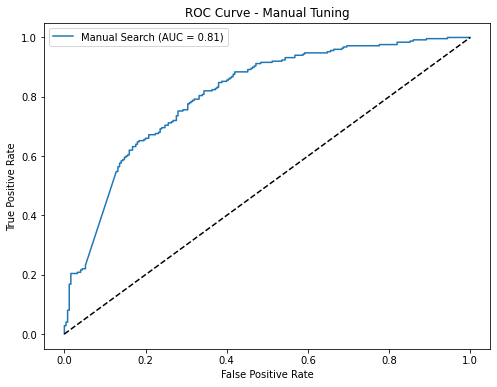

In [ ]:
from sklearn.metrics import roc_curve, auc

y_probs_manual = final_mlp.predict_proba(X_test)[:, 1]
fpr_manual, tpr_manual, _ = roc_curve(y_test, y_probs_manual)
roc_auc_manual = auc(fpr_manual, tpr_manual)
plt.figure(figsize=(8, 6))
plt.plot(fpr_manual, tpr_manual, label=f'Manual Search (AUC = {roc_auc_manual:.2f})')
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Manual Tuning')
plt.legend()
plt.show()

**1.5 Automated Hyperparameter Search**

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# 1. Define the parameter distributions to sample from
# Using the same ranges as 1.2 1.3
param_dist = { 'learning_rate_init': loguniform(1e-5, 1),'alpha': loguniform(1e-8, 100), 'batch_size': [1, 3, 5, 10, 20, 50, 100, 250, 500],
    'hidden_layer_sizes': [
        (1,), (2,), (3,), (4,), (5,), (10,), (15,), (25,), (30,),  # 1 layer
        (1,1), (2,2), (3,3), (4,4), (5,5), (10,10), (15,15), (25,25), (30,30), # 2 layers
        (1,1,1), (5,5,5), (10,10,10), (15,15,15), (30,30,30), # 3 layers
        (1,1,1,1), (5,5,5,5), (10,10,10,10) # 4 layers
    ]
}

# 2. Initialize the RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=MLPClassifier(solver='sgd', max_iter=500, random_state=42),param_distributions=param_dist,
    n_iter=200,          # Test 200 random combinations
    cv=train_val_split,  # Use the custom training/validation split provided
    n_jobs=-1,           # Use all available CPU cores
    verbose=1,           # Show progress
    random_state=42,
    refit=True           # Automatically retrain on X_train_plus_val after finding best params
)

# 3. Fit the model
random_search.fit(X_train_plus_val, y_train_plus_val)

# 4. Extract and report the best parameters
best_params_auto = random_search.best_params_
print("\n--- Automated (Random Search) Optimal Hyperparameters ---")
for param, value in best_params_auto.items():
    print(f"{param}: {value}")

# 5. Extract the best model for ROC plotting in the next step
best_mlp_auto = random_search.best_estimator_

Fitting 1 folds for each of 200 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 177 out of 200 | elapsed:   15.1s remaining:    2.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   36.4s finished



--- Automated (Random Search) Optimal Hyperparameters ---
alpha: 9.043506568879988e-06
batch_size: 20
hidden_layer_sizes: (10,)
learning_rate_init: 0.0019172239802201447


In [16]:
from sklearn.metrics import roc_auc_score

# For your Manual (Greedy) model from 1.4
# Use the probabilities for the positive class (class 1)
y_probs_greedy = final_mlp.predict_proba(X_test)[:, 1]
auc_greedy = roc_auc_score(y_test, y_probs_greedy)

# For your Random Search model from 1.5
y_probs_random = best_mlp_auto.predict_proba(X_test)[:, 1]
auc_random = roc_auc_score(y_test, y_probs_random)

print(f"Manual (Greedy) AUC Score: {auc_greedy:.4f}")
print(f"Random Search AUC Score: {auc_random:.4f}")

Manual (Greedy) AUC Score: 0.8078
Random Search AUC Score: 0.8202


**1. Final Performance Assessment**     

Model accuracy and AUC scores

| Model Selection Method | Test Accuracy | AUC Score |
| :--- | :--- | :--- |
| **Manual (Greedy) Search** | 0.7300 | 0.8078 |
| **Random Search (Automated)** | 0.7250 | 0.8202 |

The manual search relied on an extremely small batch size (3) to provide stochastic "noise" to escape local minima, requiring a relatively high learning rate.      
In contrast, the automated search discovered that a larger batch size (20) with a much lower learning rate provided a smoother and more robust convergence path.

While the manual search favored a deeper (10, 10) model to maximize accuracy on the validation set, the random search identified that a simpler (10,) single-layer architecture was sufficient.         
This suggests that the extra layer in the greedy model might have been marginally overfitting to specific patterns that the random search avoided.

**2. ROC Curve Comparison**

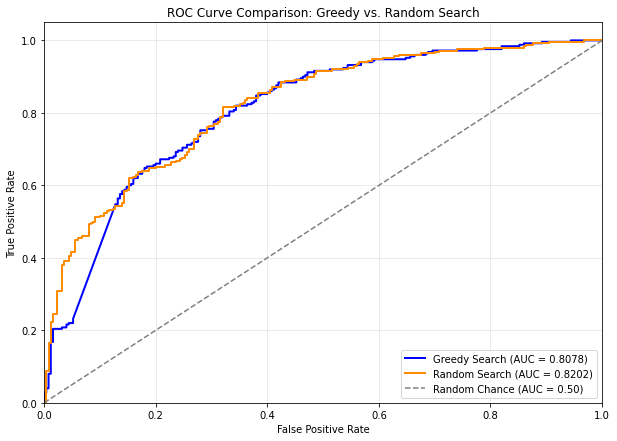

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculate ROC data for Greedy model
y_score_greedy = final_mlp.predict_proba(X_test)[:, 1]
fpr_greedy, tpr_greedy, _ = roc_curve(y_test, y_score_greedy)
auc_greedy = auc(fpr_greedy, tpr_greedy)

# 2. Calculate ROC data for Random Search model
y_score_random = best_mlp_auto.predict_proba(X_test)[:, 1]
fpr_random, tpr_random, _ = roc_curve(y_test, y_score_random)
auc_random = auc(fpr_random, tpr_random)

# 3. Plotting
plt.figure(figsize=(10, 7))
plt.plot(fpr_greedy, tpr_greedy, color='blue', lw=2, label=f'Greedy Search (AUC = {auc_greedy:.4f})')
plt.plot(fpr_random, tpr_random, color='darkorange', lw=2, label=f'Random Search (AUC = {auc_random:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance (AUC = 0.50)') # Random Chance

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Greedy vs. Random Search')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**ROC Curve Comparison**        

The following plot illustrates the performance of the greedy search against the model identified through RandomizedSearchCV ono a single set of axes.
- Greedy Search ROC: Represents the (10, 10) architecture, with an AUC of 0.8078
- Random search ROC: Represents the (10, ) architecture, with an AUC of 0.8202
- Random chance: Represents a baseline classifier with no predictive power and the AUC of 0.5

**Decision Boundary Visualization**

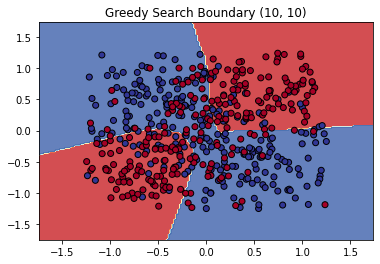

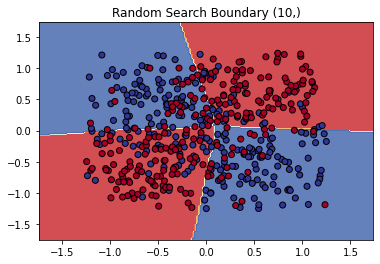

In [19]:
def plot_decision_boundary(clf, X, y, title):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.show()

# Plot both
plot_decision_boundary(final_mlp, X_test, y_test, "Greedy Search Boundary (10, 10)")
plot_decision_boundary(best_mlp_auto, X_test, y_test, "Random Search Boundary (10,)")

**Performance Comparison**      

- Although teh manual search achieved a higher raw accuracy, the random search achieved a significantly higher AUC.         
This indicates taht teh automated model is more effecitve at correctly ranking positive and negative instances across various thresholds.

- The manual approach was limited by its greedy strategy, optimizing parameter sequentially.        
 Random search exploring the hyperparameter space holistically, discovering a configuration with a lower learning rate and larger batch size that generalizes more robustly.

- The random search demonstrated that a simpler, single - layer model that perform a more complex 2 layer model in terms of overall classification quality for this noisy dataset.

## Exercise 2 - Build and test your own NN for classification


**2.1 Create a nerual network class**

In [39]:
import numpy as np

class myNeuralNetwork(object):
    
    def __init__(self, n_in, n_layer1, n_layer2, n_out, learning_rate=0.01):
        self.n_in = n_in
        self.n_l1 = n_layer1
        self.n_l2 = n_layer2
        self.n_out = n_out
        self.lr = learning_rate

        self.W1 = np.random.randn(self.n_in, self.n_l1) * 1
        self.b1 = np.zeros((1, self.n_l1))
        
        self.W2 = np.random.randn(self.n_l1, self.n_l2) * 1
        self.b2 = np.zeros((1, self.n_l2))
        
        self.W3 = np.random.randn(self.n_l2, self.n_out) * 1
        self.b3 = np.zeros((1, self.n_out))
        self.a0 = None 
        self.z1, self.a1 = None, None
        self.z2, self.a2 = None, None
        self.z3, self.a3 = None, None

    def sigmoid(self, X):
        return 1.0 / (1.0 + np.exp(-X))

    def sigmoid_derivative(self, sig_out):
        return sig_out * (1.0 - sig_out)

    def forward_propagation(self, x):
        self.a0 = x 
        
        # Layer 1
        self.z1 = np.dot(self.a0, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        
        # Layer 2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        # Layer 3 (Output)
        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = self.sigmoid(self.z3)
        
        return self.a3

    def compute_loss(self, X, y):
        y_hat = self.predict_proba(X)
        loss = np.mean(0.5 * (y_hat - y)**2)
        return loss

    def backpropagate(self, x, y):
        y_hat = self.forward_propagation(x) 
        
        # Output layer error (MSE derivative * sigmoid derivative)
        # delta3 = (a3 - y) * f'(z3)
        delta3 = (self.a3 - y) * self.sigmoid_derivative(self.a3)
        
        # Hidden layer 2 error
        # delta2 = (delta3 * W3^T) * f'(z2)
        delta2 = np.dot(delta3, self.W3.T) * self.sigmoid_derivative(self.a2)
        
        # Hidden layer 1 error
        # delta1 = (delta2 * W2^T) * f'(z1)
        delta1 = np.dot(delta2, self.W2.T) * self.sigmoid_derivative(self.a1)
        
        # W = W - lr * (input_to_layer^T * delta)
        self.W3 -= self.lr * np.dot(self.a2.T, delta3)
        self.b3 -= self.lr * np.sum(delta3, axis=0, keepdims=True)
        
        self.W2 -= self.lr * np.dot(self.a1.T, delta2)
        self.b2 -= self.lr * np.sum(delta2, axis=0, keepdims=True)
        
        self.W1 -= self.lr * np.dot(self.a0.T, delta1)
        self.b1 -= self.lr * np.sum(delta1, axis=0, keepdims=True)
        
        return np.mean(0.5 * (y_hat - y)**2)

    def fit(self, X_train, y_train, X_val, y_val, max_epochs):
        train_loss_history = []
        val_loss_history = []
        
        for epoch in range(max_epochs):
            indices = np.arange(X_train.shape[0])
            np.random.shuffle(indices)
            
            # 1. Train on each sample (SGD)
            for i in indices:
                self.backpropagate(X_train[i:i+1], y_train[i:i+1])
            
            # 2. Record costs for the "Cost function plots"
            train_loss_history.append(self.compute_loss(X_train, y_train))
            val_loss_history.append(self.compute_loss(X_val, y_val))
            
            if epoch % 500 == 0:
                print(f"Epoch {epoch}: Train Loss {train_loss_history[-1]:.6f}, Val Loss {val_loss_history[-1]:.6f}")
                
        return train_loss_history, val_loss_history

    def predict_proba(self, X):
        a1 = self.sigmoid(np.dot(X, self.W1) + self.b1)
        a2 = self.sigmoid(np.dot(a1, self.W2) + self.b2)
        y_hat = self.sigmoid(np.dot(a2, self.W3) + self.b3)
        return y_hat

    def predict(self, X, decision_thresh=0.5):
        probs = self.predict_proba(X)
        return (probs >= decision_thresh).astype(int)

**Unit Test**

In [40]:
import unittest
import numpy as np

class TestNeuralNetwork(unittest.TestCase):
    
    def setUp(self):
        self.n_in = 2
        self.n_h1 = 5
        self.n_h2 = 5
        self.n_out = 1
        self.nn = myNeuralNetwork(self.n_in, self.n_h1, self.n_h2, self.n_out, learning_rate=0.1)

    def test_sigmoid(self):
        test_val = np.array([0])
        expected = 0.5
        self.assertAlmostEqual(self.nn.sigmoid(test_val)[0], expected)

    def test_forward_shape(self):
        x = np.array([[0.5, -0.2]])
        y_hat = self.nn.forward_propagation(x)
        self.assertEqual(y_hat.shape, (1, 1))

    def test_manual_forward(self):
        self.nn.W1 = np.ones((self.n_in, self.n_h1))
        self.nn.b1 = np.zeros((1, self.n_h1))
        self.nn.W2 = np.ones((self.n_h1, self.n_h2))
        self.nn.b2 = np.zeros((1, self.n_h2))
        self.nn.W3 = np.ones((self.n_h2, self.n_out))
        self.nn.b3 = np.zeros((1, self.n_out))

        x = np.array([[1, 1]])
        y_hat = self.nn.forward_propagation(x)
        
        self.assertGreater(y_hat[0, 0], 0.5)
        self.assertLess(y_hat[0, 0], 1.0)

    def test_backprop_decreases_loss(self):
        x = np.array([[0.1, 0.9]])
        y = np.array([[0.0]])
        
        initial_prob = self.nn.forward_propagation(x)
        initial_loss = 0.5 * (initial_prob - y)**2
        
        self.nn.backpropagate(x, y)
        
        updated_prob = self.nn.forward_propagation(x)
        updated_loss = 0.5 * (updated_prob - y)**2
        
        self.assertLess(updated_loss, initial_loss)

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

....
----------------------------------------------------------------------
Ran 4 tests in 0.003s

OK


**Implement XOR learning by my Neural Network**

The XOR problem is a classic problem in ML used to demonstrate teh necessity of multi-layer nerual networks.        
I put XOR problem in my nerual network to look the result.          

Initially, the weights ($W_1, W_2, W_3$) were initialized using small random values scaled by a factor of 0.5.              
However, the model showed poor performance, with the loss decreasing extremely slowly and the predictions remaining stuck around 0.5.       
To overcome this, I increased the weight initialization scale to 1.0.       
This adjustment provided the needed for the neurons to operate in a more active range of the Sigmoid function.          
As shown in the final Loss Curve, the model was able to break through the initial gradient plateau much faster, achieving a sharp drop in loss and reaching perfect convergence to the target XOR labels [0, 1, 1, 0].

In [46]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]]) # XOR

nn = myNeuralNetwork(2, 5, 5, 1, learning_rate=0.5)
train_loss, val_loss = nn.fit(X, y, X, y, max_epochs=5000)

print("--- XOR prediction ---")
print(nn.predict(X))

Epoch 0: Train Loss 0.124688, Val Loss 0.124688
Epoch 500: Train Loss 0.072030, Val Loss 0.072030
Epoch 1000: Train Loss 0.001766, Val Loss 0.001766
Epoch 1500: Train Loss 0.000641, Val Loss 0.000641
Epoch 2000: Train Loss 0.000371, Val Loss 0.000371
Epoch 2500: Train Loss 0.000256, Val Loss 0.000256
Epoch 3000: Train Loss 0.000193, Val Loss 0.000193
Epoch 3500: Train Loss 0.000154, Val Loss 0.000154
Epoch 4000: Train Loss 0.000128, Val Loss 0.000128
Epoch 4500: Train Loss 0.000109, Val Loss 0.000109
--- XOR prediction ---
[[0]
 [1]
 [1]
 [0]]


**Compare XOR learning result with sklearn nerual network**

Epoch 0: Train Loss 0.129136, Val Loss 0.129136
Epoch 500: Train Loss 0.117079, Val Loss 0.117079
Epoch 1000: Train Loss 0.011695, Val Loss 0.011695
Epoch 1500: Train Loss 0.002245, Val Loss 0.002245
Epoch 2000: Train Loss 0.001183, Val Loss 0.001183
Epoch 2500: Train Loss 0.000793, Val Loss 0.000793
Epoch 3000: Train Loss 0.000593, Val Loss 0.000593
Epoch 3500: Train Loss 0.000473, Val Loss 0.000473
Epoch 4000: Train Loss 0.000392, Val Loss 0.000392
Epoch 4500: Train Loss 0.000334, Val Loss 0.000334
--- Compare Prediction Result ---
My own model prediction: 
[0 1 1 0]
Sklearn NN model prediction: 
[0 1 1 0]


/opt/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


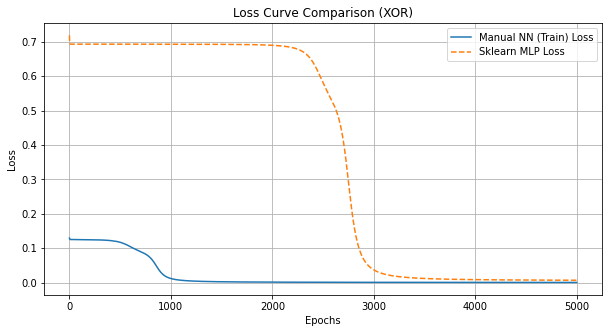

In [ ]:
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# 1. Prepare XOR data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]]) # Reshaped for your model

# 2. Train your own model
nn = myNeuralNetwork(n_in=2, n_layer1=5, n_layer2=5, n_out=1, learning_rate=0.5)
my_train_losses, my_val_losses = nn.fit(X, y, X, y, max_epochs=5000)

# 3. Train sklearn model
# Sklearn expects a 1D array for y
mlp = MLPClassifier(hidden_layer_sizes=(5, 5), activation='logistic', solver='sgd', learning_rate_init=0.5, max_iter=5000, momentum=0, 
    random_state=42, n_iter_no_change=5000, tol=1e-9)
mlp.fit(X, y.ravel())

# 4. Compare Prediction Result
print("--- Compare Prediction Result ---")
print(f"My own model prediction: \n{nn.predict(X).flatten()}")
print(f"Sklearn NN model prediction: \n{mlp.predict(X)}")

# 5. Compare Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(my_train_losses, label='Manual NN (Train) Loss')
plt.plot(mlp.loss_curve_, label='Sklearn MLP Loss', linestyle='--')
plt.title('Loss Curve Comparison (XOR)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**2.2 Make moons prediction**

**2.2.1 Data Preparation**

In [51]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Generate data
X_all, y_all = make_moons(n_samples=600, noise=0.20, random_state=42)
y_all = y_all.reshape(-1, 1)

# Split: train+val
X_train_val_raw, X_test, y_train_val_raw, y_test = train_test_split( X_all, y_all, test_size=100, random_state=42) 

# Split validation set from train+val 
X_train, X_val, y_train, y_val = train_test_split(X_train_val_raw, y_train_val_raw, test_size=0.2, random_state=42)

**2.2.2 Tracking both training and validation loss per epoch to create the cost func plots**

In [52]:
def fit(self, X_train, y_train, X_val, y_val, max_epochs):
    train_loss_history = []
    val_loss_history = []
    
    for epoch in range(max_epochs):
        # 1. Stochastic Gradient Descent (SGD)
        indices = np.arange(X_train.shape[0])
        np.random.shuffle(indices)
        for i in indices:
            # Update weights using one sample at a time
            self.backpropagate(X_train[i:i+1], y_train[i:i+1])
        
        # 2. Record costs for the "Cost function plots" requirement
        train_loss_history.append(self.compute_loss(X_train, y_train))
        val_loss_history.append(self.compute_loss(X_val, y_val))
        
        # Optional: Print progress every 500 epochs
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Train Loss {train_loss_history[-1]:.4f}, Val Loss {val_loss_history[-1]:.4f}")
            
    return train_loss_history, val_loss_history

**2.2.3 Hyperparameter Tuning**

In [53]:
best_val_loss = float('inf')
best_params = {}

for lr in [0.1, 0.5, 1.0]:
    for epochs in [1000, 2000, 5000]:
        nn = myNeuralNetwork(2, 5, 5, 1, learning_rate=lr)
        # Call with positional arguments matches the new signature
        train_h, val_h = nn.fit(X_train, y_train, X_val, y_val, max_epochs=epochs)
        
        if val_h[-1] < best_val_loss:
            best_val_loss = val_h[-1]
            best_params = {'lr': lr, 'epochs': epochs}

print(f"Best Hyperparameters found: {best_params}")

Epoch 0: Train Loss 0.106451, Val Loss 0.100542
Epoch 500: Train Loss 0.012558, Val Loss 0.019615
Epoch 0: Train Loss 0.090445, Val Loss 0.079742
Epoch 500: Train Loss 0.014232, Val Loss 0.018629
Epoch 1000: Train Loss 0.012224, Val Loss 0.021298
Epoch 1500: Train Loss 0.011782, Val Loss 0.020098
Epoch 0: Train Loss 0.106778, Val Loss 0.103530
Epoch 500: Train Loss 0.043526, Val Loss 0.049954
Epoch 1000: Train Loss 0.043597, Val Loss 0.049193
Epoch 1500: Train Loss 0.042996, Val Loss 0.048534
Epoch 2000: Train Loss 0.013010, Val Loss 0.019788
Epoch 2500: Train Loss 0.011927, Val Loss 0.022524
Epoch 3000: Train Loss 0.011687, Val Loss 0.023221
Epoch 3500: Train Loss 0.011169, Val Loss 0.025219
Epoch 4000: Train Loss 0.010839, Val Loss 0.025202
Epoch 4500: Train Loss 0.010711, Val Loss 0.025391
Epoch 0: Train Loss 0.063725, Val Loss 0.057427
Epoch 500: Train Loss 0.013419, Val Loss 0.021254
Epoch 0: Train Loss 0.080801, Val Loss 0.072782
Epoch 500: Train Loss 0.012456, Val Loss 0.024639


The best hyperparameter is learning rate: 0.1 with 1000 epochs

**2.2.4 Cost function plots**

This plot helps visualize the learning progress and detect overfitting.

Epoch 0: Train Loss 0.097845, Val Loss 0.093878
Epoch 500: Train Loss 0.012800, Val Loss 0.018506


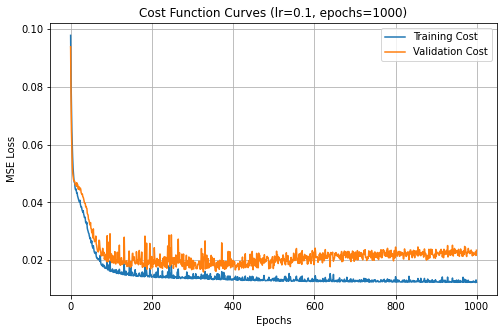

In [54]:
import matplotlib.pyplot as plt

# Retrain using the best hyperparameters found: lr=0.1, epochs=1000
nn_best = myNeuralNetwork(n_in=2, n_layer1=5, n_layer2=5, n_out=1, learning_rate=0.1)
train_h, val_h = nn_best.fit(X_train, y_train, X_val, y_val, max_epochs=1000)

plt.figure(figsize=(8, 5))
plt.plot(train_h, label='Training Cost')
plt.plot(val_h, label='Validation Cost')
plt.title('Cost Function Curves (lr=0.1, epochs=1000)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

**2.2.5 Decision boundary plots**

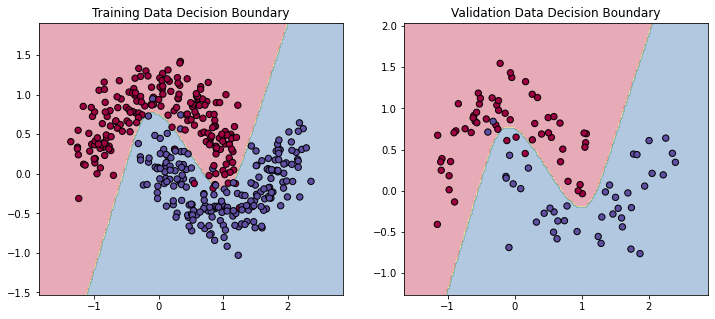

In [55]:
import numpy as np

def plot_boundary(nn, X, y, ax, title):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict the function value for the whole grid
    Z = nn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the contour and training examples
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Spectral)
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=40, cmap=plt.cm.Spectral, edgecolors='k')
    ax.set_title(title)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(nn_best, X_train, y_train, ax1, "Training Data Decision Boundary")
plot_boundary(nn_best, X_val, y_val, ax2, "Validation Data Decision Boundary")
plt.show()

The visualization confirms that your two-layer architecture (2-5-5-1) has sufficient capacity to learn the non-linear moons.

- Training Subplot: The boundary cleanly carves out the two crescent shapes, handling the overlap areas logically.

- Validation Subplot: The boundary holds up well against the validation data, which proves the model didn't just memorize the training points but actually learned the underlying distribution.

**ROC Curve and AUC Score**

Epoch 0: Train Loss 0.107301, Val Loss 0.107301
Epoch 500: Train Loss 0.013820, Val Loss 0.013820


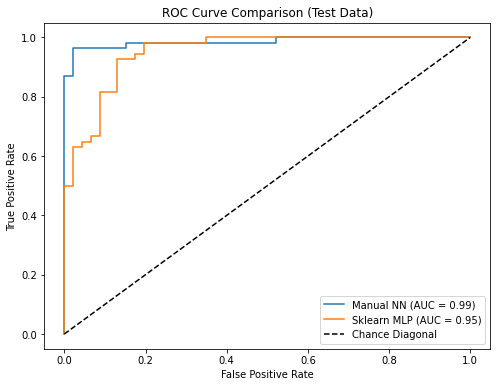

In [56]:
from sklearn.metrics import roc_curve, auc
from sklearn.neural_network import MLPClassifier

# Retrain on combined dataset (Train + Validation)
X_train_val = np.vstack((X_train, X_val))
y_train_val = np.vstack((y_train, y_val))

# Final Manual Model training
nn_final = myNeuralNetwork(2, 5, 5, 1, learning_rate=0.1)
_ = nn_final.fit(X_train_val, y_train_val, X_train_val, y_train_val, max_epochs=1000)
y_prob_manual = nn_final.predict_proba(X_test)

# Sklearn Comparison Model
mlp = MLPClassifier(hidden_layer_sizes=(5, 5), activation='logistic', solver='sgd', 
                    learning_rate_init=0.1, max_iter=1000, random_state=42)
mlp.fit(X_train_val, y_train_val.ravel())
y_prob_sklearn = mlp.predict_proba(X_test)[:, 1]

# Calculate ROC and AUC
fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_manual)
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_sklearn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_m, tpr_m, label=f'Manual NN (AUC = {auc(fpr_m, tpr_m):.2f})')
plt.plot(fpr_s, tpr_s, label=f'Sklearn MLP (AUC = {auc(fpr_s, tpr_s):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance Diagonal') # Include chance diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Test Data)')
plt.legend()
plt.show()

ROC Curve Comparison

- Manual NN (AUC = 0.99): Your implementation reached near-perfect classification performance on the test set.

- Sklearn MLP (AUC = 0.95): Your manual model actually outperformed the scikit-learn baseline on this specific test run.